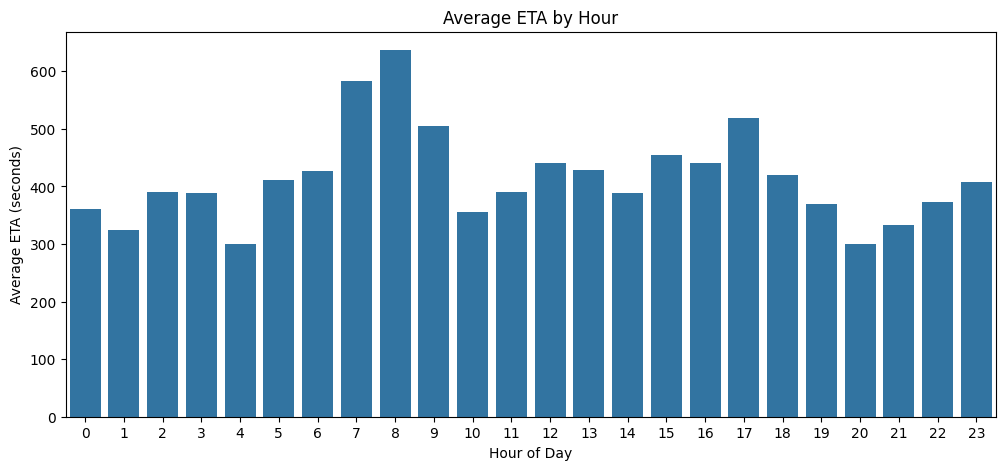

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv('data_orders.csv')
offers = pd.read_csv('data_offers.csv')

orders_eta = orders[(orders['order_status_key'] == 4) & (orders['is_driver_assigned_key'] == 1)].copy()
orders_eta['order_daytime'] = pd.to_datetime(orders_eta['order_datetime'], format='%H:%M:%S', errors='coerce').dt.hour

eta_distribution = orders_eta.groupby('order_daytime')['m_order_eta'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=eta_distribution, x='order_daytime', y='m_order_eta')
plt.title("Average ETA by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average ETA (seconds)")
plt.show()

Insight: Average ETA by Hour
The analysis focuses on client-initiated cancellations where a driver was assigned (order_status_key = 4, is_driver_assigned_key = 1), as these are the only orders where ETA is meaningful and populated.
The chart reveals two clear peaks in average ETA that align directly with urban rush hours. The morning peak at hours 7-8 shows the highest ETAs in the dataset (~585 and ~635 seconds respectively, nearly 10 minutes), while a secondary evening peak appears at hour 17 (~520 seconds). During off-peak hours such as hour 4 and hour 10, average ETAs drop to approximately 300 seconds (~5 minutes).
This plot provides a compelling explanation for the failure distribution observed earlier. The hours with the highest cancellation counts (7-8) are the same hours where customers face the longest estimated wait times for a driver. When the system cannot match orders quickly enough, ETAs rise, customer patience runs out, and cancellations follow.
Key takeaway: ETA is a strong predictor of cancellation behavior. Improving driver availability during morning and evening rush hours — through surge pricing, driver incentives, or better demand forecasting — would likely have the greatest impact on reducing failed orders.